<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/
master/notebooks/statistics/OilandGasPriceStatistics.ipynb"
target="_parent"><img
src="https://colab.research.google.com/assets/colab-badge.svg"
alt="Open In Colab"/></a>

# Oil and gas prices translated into a NeqSim export-gas netback

**Intended audience.** Process, production, and energy engineers who need to
connect public commodity-price statistics to physical gas-processing costs.

**Prerequisites.** Basic Python, descriptive statistics, thermodynamics, and
process simulation. All engineering calculations use SI units; the public
market quotations retain their conventional USD/bbl and USD/MMBtu units.

## Learning objectives

After completing this tutorial, you can:

1. preserve and reproduce the original Brent and Henry Hub price workflows;
2. distinguish source observations from explicit engineering assumptions;
3. compare oil and gas prices on a common energy basis;
4. model a sales-gas fluid with SRK and calculate ISO 6976 gas quality;
5. connect a stream, compressor, aftercooler, and scrubber in NeqSim;
6. translate shaft power into a price-dependent processing netback; and
7. test pressure, electricity-price, and commodity-price sensitivities.

In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path


# Original topic: internal transfer-price context for Norwegian oil and gas.
os.environ.setdefault(
    "MPLCONFIGDIR",
    "/tmp/matplotlib-oil-gas-price-statistics",
)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

The preserved setup cell now installs the current public-PyPI `neqsim` package
only when it is absent. It does not use a repository checkout, private wheel,
hidden data file, or runtime restart.

In [2]:
import platform
import subprocess
from importlib.metadata import version

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import YouTubeVideo, display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

import neqsim
from neqsim.process import (
    clearProcess,
    compressor,
    cooler,
    separator,
    stream,
)
from neqsim.thermo import TPflash, fluid


ISO6976_2016 = jpype.JClass(
    "neqsim.standards.gasquality.Standard_ISO6976_2016"
)

plt.rcParams.update(
    {
        "axes.grid": True,
        "figure.dpi": 120,
        "figure.figsize": (9, 5),
        "font.size": 10,
        "grid.alpha": 0.25,
    }
)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
}

## Literature and original resources

The following links were present in the original notebook and remain useful
background:

- [EIA Short-Term Energy Outlook price discussion](
  https://www.eia.gov/outlooks/steo/report/prices.php)
- [Medium: reading data into a pandas DataFrame](
  https://medium.com/@zachary.bedell/
  how-to-read-data-into-a-pandas-dataframe-from-a-url-1b5e6f304a6b)
- [Towards Data Science: importing datasets from URLs](
  https://towardsdatascience.com/
  how-to-import-a-dataset-from-a-url-in-jupyter-notebook-a1b6e14fbead)
- [Norwegian Petroleum](
  https://www.norskpetroleum.no/en/)

Authoritative price series used below are the U.S. Energy Information
Administration (EIA) Europe Brent spot price and Henry Hub natural-gas spot
price.

## 1. Reproducible EIA price snapshot

The original notebook downloaded two Excel workbooks and skipped a fixed number
of rows. That made results depend on workbook growth and network availability.
This repair keeps both workbook URLs and the original plotting intent, but
embeds the official monthly values visible on the EIA history pages when
retrieved on 27 July 2026.

- Brent: January 2020 through June 2026, USD/bbl.
- Henry Hub: January 2020 through June 2026, USD/MMBtu.

The embedded snapshot is immutable and auditable. A reusable Excel helper is
supplied for an analyst who deliberately wants a newer online extract.

In [3]:
YouTubeVideo("66ueFfrts00", width=700, height=400)

Out[3]: <IPython.lib.display.YouTubeVideo at 0x7fed512203e0>


In [4]:
BRENT_XLS_URL = "https://www.eia.gov/dnav/pet/hist_xls/RBRTEd.xls"
HENRY_HUB_XLS_URL = (
    "https://www.eia.gov/dnav/ng/hist_xls/RNGWHHDd.xls"
)

monthly_values = {
    "Brent [USD/bbl]": {
        2020: [
            63.65, 55.66, 32.01, 18.38, 29.38, 40.27,
            43.24, 44.74, 40.91, 40.19, 42.69, 49.99,
        ],
        2021: [
            54.77, 62.28, 65.41, 64.81, 68.53, 73.16,
            75.17, 70.75, 74.49, 83.54, 81.05, 74.17,
        ],
        2022: [
            86.51, 97.13, 117.25, 104.58, 113.34, 122.71,
            111.93, 100.45, 89.76, 93.33, 91.42, 80.92,
        ],
        2023: [
            82.50, 82.59, 78.43, 84.64, 75.47, 74.84,
            80.11, 86.15, 93.72, 90.60, 82.94, 77.63,
        ],
        2024: [
            80.12, 83.48, 85.41, 89.94, 81.75, 82.25,
            85.15, 80.36, 74.02, 75.63, 74.35, 73.86,
        ],
        2025: [
            79.27, 75.44, 72.73, 68.13, 64.45, 71.44,
            71.04, 67.87, 67.99, 64.54, 63.80, 62.54,
        ],
        2026: [66.60, 70.89, 103.13, 117.29, 107.14, 86.11],
    },
    "Henry Hub [USD/MMBtu]": {
        2020: [
            2.02, 1.91, 1.79, 1.74, 1.75, 1.63,
            1.76, 2.30, 1.92, 2.39, 2.61, 2.58,
        ],
        2021: [
            2.71, 5.35, 2.62, 2.66, 2.91, 3.26,
            3.84, 4.07, 5.16, 5.51, 5.05, 3.76,
        ],
        2022: [
            4.38, 4.69, 4.90, 6.60, 8.14, 7.70,
            7.28, 8.81, 7.88, 5.66, 5.45, 5.53,
        ],
        2023: [
            3.27, 2.38, 2.31, 2.16, 2.15, 2.18,
            2.55, 2.58, 2.64, 2.98, 2.71, 2.52,
        ],
        2024: [
            3.18, 1.72, 1.49, 1.60, 2.12, 2.54,
            2.07, 1.99, 2.28, 2.20, 2.12, 3.01,
        ],
        2025: [
            4.13, 4.19, 4.12, 3.42, 3.12, 3.02,
            3.20, 2.91, 2.97, 3.19, 3.79, 4.26,
        ],
        2026: [7.72, 3.62, 3.04, 2.77, 2.94, 3.15],
    },
}


def monthly_series(name, values_by_year):
    records = []
    for year, values in values_by_year.items():
        for month, value in enumerate(values, start=1):
            records.append(
                {
                    "Date": pd.Timestamp(year=year, month=month, day=1),
                    name: value,
                }
            )
    return pd.DataFrame(records)


brent_monthly = monthly_series(
    "Brent [USD/bbl]",
    monthly_values["Brent [USD/bbl]"],
)
henry_hub_monthly = monthly_series(
    "Henry Hub [USD/MMBtu]",
    monthly_values["Henry Hub [USD/MMBtu]"],
)


def read_eia_history_workbook(url, sheet_name="Data 1"):
    return pd.read_excel(url, sheet_name=sheet_name, skiprows=2)


print(
    "Embedded EIA snapshot:",
    brent_monthly["Date"].min().date(),
    "to",
    brent_monthly["Date"].max().date(),
)

Embedded EIA snapshot: 2020-01-01 to 2026-06-01


### Preserved example A — Brent spot-price history

This is the original Brent workflow, repaired to plot the embedded official
monthly snapshot rather than relying on a row number in a changing workbook.
The figure retains the original purpose: reveal the price level, the 2020
collapse, the 2022 peak, and subsequent volatility.

,Date,Brent Price
70,2025-11-01,63.80
71,2025-12-01,62.54
72,2026-01-01,66.60
73,2026-02-01,70.89
74,2026-03-01,103.13
75,2026-04-01,117.29
76,2026-05-01,107.14
77,2026-06-01,86.11


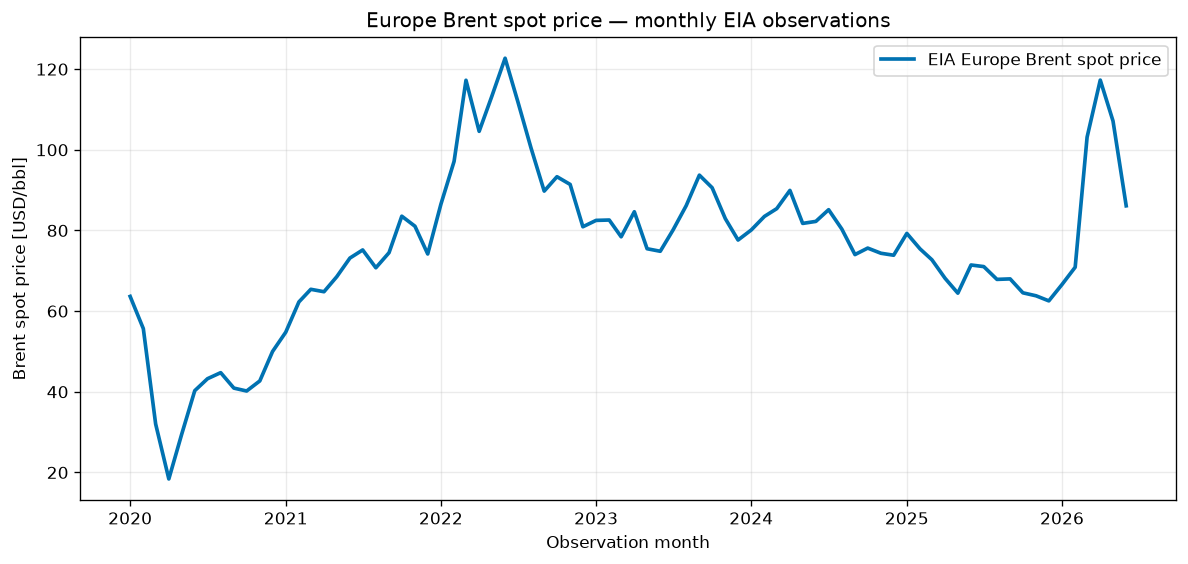

In [5]:
brent_price = brent_monthly.rename(
    columns={"Brent [USD/bbl]": "Brent Price"}
).copy()

display(brent_price.tail(8))

figure, axis = plt.subplots(figsize=(10, 4.8))
axis.plot(
    brent_price["Date"],
    brent_price["Brent Price"],
    color=COLORS["blue"],
    linewidth=2.2,
    label="EIA Europe Brent spot price",
)
axis.set_title("Europe Brent spot price — monthly EIA observations")
axis.set_xlabel("Observation month")
axis.set_ylabel("Brent spot price [USD/bbl]")
axis.legend()

figure.tight_layout()
plt.show()

Brent fell below 20 USD/bbl in April 2020 and exceeded 120 USD/bbl in June
2022. The latest embedded month is June 2026. These are historical spot
observations, not a forecast and not a Norwegian fiscal reference price.

### Preserved example B — Henry Hub natural-gas spot price

The second original workflow is retained with the same repair. Henry Hub is a
U.S. benchmark; it is used here to teach units and price sensitivity, not as a
substitute for European hub prices or a project sales contract.

,Date,Henry Hub Price
70,2025-11-01,3.79
71,2025-12-01,4.26
72,2026-01-01,7.72
73,2026-02-01,3.62
74,2026-03-01,3.04
75,2026-04-01,2.77
76,2026-05-01,2.94
77,2026-06-01,3.15


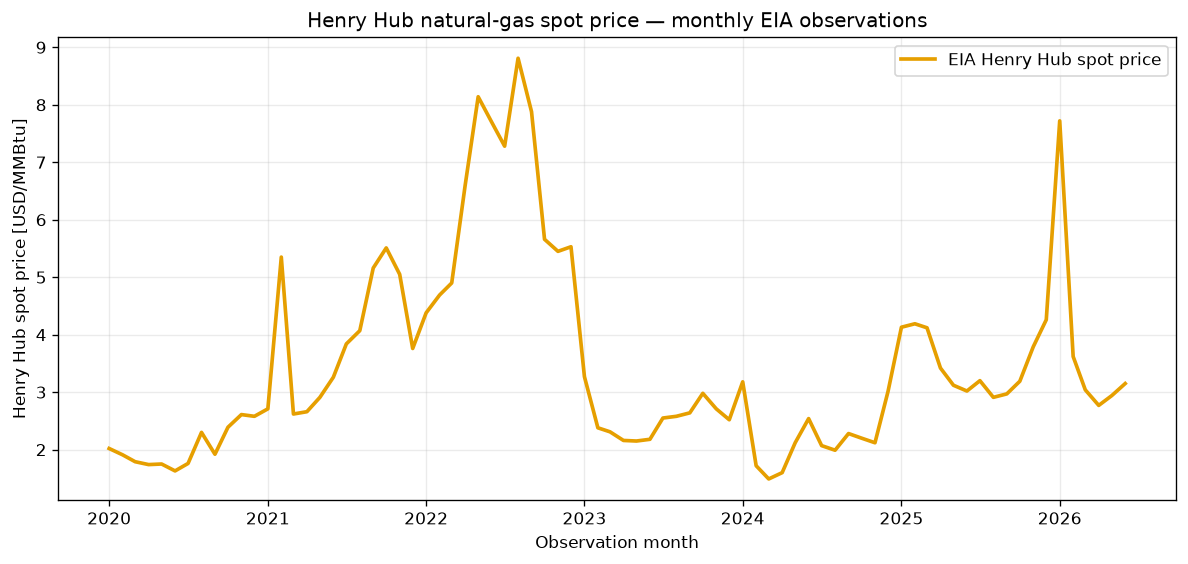

In [6]:
henry_hub_price = henry_hub_monthly.rename(
    columns={"Henry Hub [USD/MMBtu]": "Henry Hub Price"}
).copy()

display(henry_hub_price.tail(8))

figure, axis = plt.subplots(figsize=(10, 4.8))
axis.plot(
    henry_hub_price["Date"],
    henry_hub_price["Henry Hub Price"],
    color=COLORS["orange"],
    linewidth=2.2,
    label="EIA Henry Hub spot price",
)
axis.set_title("Henry Hub natural-gas spot price — monthly EIA observations")
axis.set_xlabel("Observation month")
axis.set_ylabel("Henry Hub spot price [USD/MMBtu]")
axis.legend()

figure.tight_layout()
plt.show()

The gas series shows a different cycle from Brent: the 2022 peak reflects a
gas-specific market shock, while 2024 remained comparatively weak. Commodity
prices should therefore enter a scenario analysis as separate drivers.

## 2. Descriptive statistics on a common energy basis

Let $p_t$ denote a monthly price. The sample arithmetic mean and coefficient of
variation are:

$$
\bar{p} = \frac{1}{n}\sum_{t=1}^{n} p_t
$$

$$
CV = \frac{s_p}{\bar{p}}
$$

Brent is converted only for comparison using 5.8 MMBtu per barrel of oil
equivalent:

$$
p_{\mathrm{oil,energy}} = \frac{p_{\mathrm{Brent}}}{5.8}
$$

This is an energy-equivalent indicator. It does not account for refining value,
transport, location, quality, taxes, contracts, or currency exposure.

In [7]:
price_history = brent_monthly.merge(
    henry_hub_monthly,
    on="Date",
    how="inner",
    validate="one_to_one",
)
price_history["Brent energy equivalent [USD/MMBtu]"] = (
    price_history["Brent [USD/bbl]"] / 5.8
)
price_history["Energy-equivalent spread [USD/MMBtu]"] = (
    price_history["Brent energy equivalent [USD/MMBtu]"]
    - price_history["Henry Hub [USD/MMBtu]"]
)
price_history["Rolling correlation [-]"] = (
    price_history["Brent energy equivalent [USD/MMBtu]"]
    .rolling(window=12, min_periods=8)
    .corr(price_history["Henry Hub [USD/MMBtu]"])
)

recent_price_history = price_history.tail(8).copy()
numeric_columns = recent_price_history.select_dtypes(
    include="number"
).columns
recent_price_history[numeric_columns] = (
    recent_price_history[numeric_columns].round(3)
)
display(recent_price_history)

,Date,Brent [USD/bbl],Henry Hub [USD/MMBtu],Brent energy equivalent [USD/MMBtu],Energy-equivalent spread [USD/MMBtu],Rolling correlation [-]
70,2025-11-01,63.80,3.79,11.000,7.210,0.494
71,2025-12-01,62.54,4.26,10.783,6.523,0.316
72,2026-01-01,66.60,7.72,11.483,3.763,-0.060
73,2026-02-01,70.89,3.62,12.222,8.602,-0.143
74,2026-03-01,103.13,3.04,17.781,14.741,-0.204
75,2026-04-01,117.29,2.77,20.222,17.452,-0.284
76,2026-05-01,107.14,2.94,18.472,15.532,-0.346
77,2026-06-01,86.11,3.15,14.847,11.697,-0.374


In [8]:
statistics_rows = []
for column in [
    "Brent [USD/bbl]",
    "Henry Hub [USD/MMBtu]",
    "Brent energy equivalent [USD/MMBtu]",
]:
    series = price_history[column]
    statistics_rows.append(
        {
            "Series": column,
            "Mean": series.mean(),
            "Standard deviation": series.std(ddof=1),
            "Coefficient of variation": (
                series.std(ddof=1) / series.mean()
            ),
            "P10": series.quantile(0.10),
            "Median": series.median(),
            "P90": series.quantile(0.90),
        }
    )

price_statistics = pd.DataFrame(statistics_rows)
display(price_statistics.round(3))

,Series,Mean,Standard deviation,Coefficient of variation,P10,Median,P90
0,Brent [USD/bbl],75.576,20.336,0.269,44.290,75.455,101.254
1,Henry Hub [USD/MMBtu],3.470,1.720,0.496,1.874,2.955,5.569
2,Brent energy equivalent [USD/MMBtu],13.030,3.506,0.269,7.636,13.009,17.458


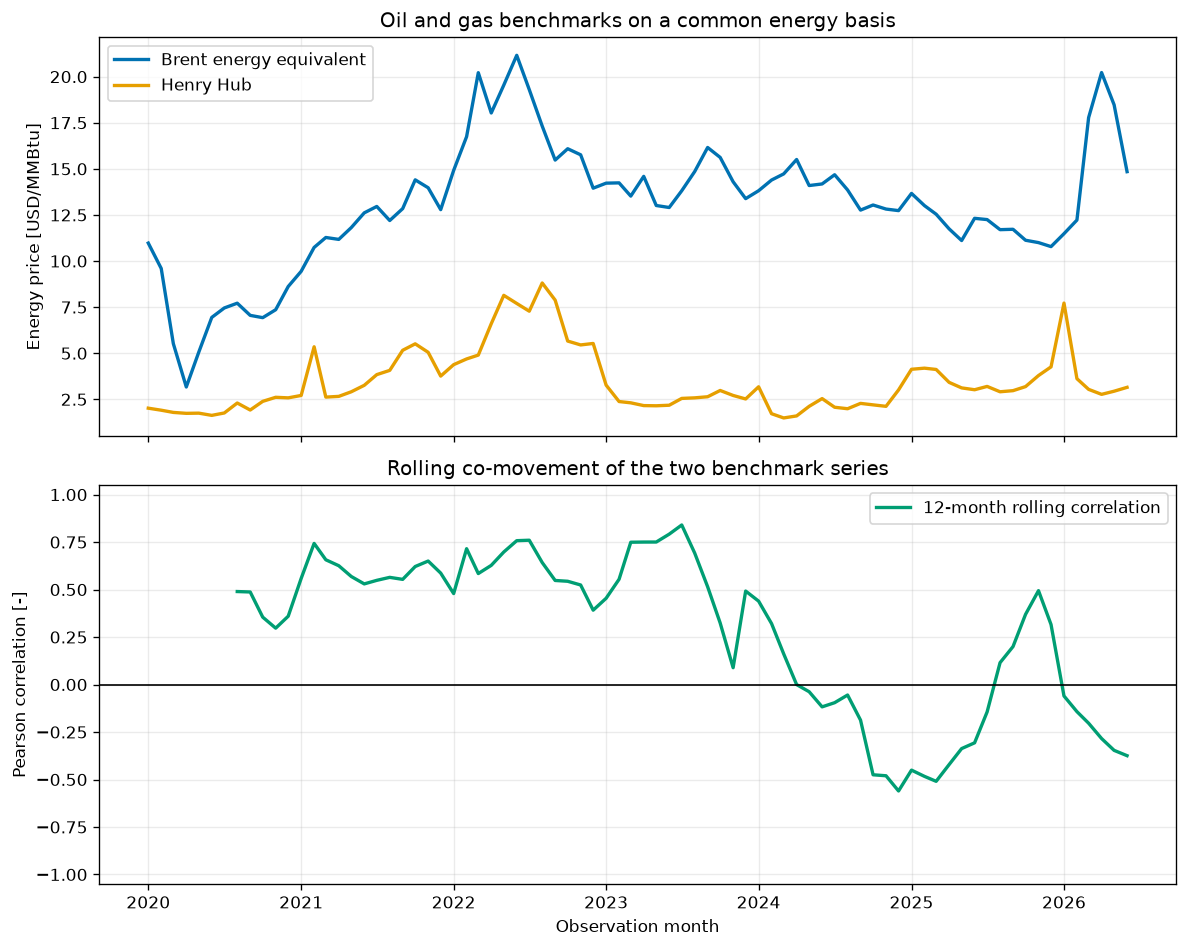

In [9]:
figure, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(
    price_history["Date"],
    price_history["Brent energy equivalent [USD/MMBtu]"],
    color=COLORS["blue"],
    linewidth=2.0,
    label="Brent energy equivalent",
)
axes[0].plot(
    price_history["Date"],
    price_history["Henry Hub [USD/MMBtu]"],
    color=COLORS["orange"],
    linewidth=2.0,
    label="Henry Hub",
)
axes[0].set_title("Oil and gas benchmarks on a common energy basis")
axes[0].set_ylabel("Energy price [USD/MMBtu]")
axes[0].legend()

axes[1].plot(
    price_history["Date"],
    price_history["Rolling correlation [-]"],
    color=COLORS["green"],
    linewidth=2.0,
    label="12-month rolling correlation",
)
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].set_title("Rolling co-movement of the two benchmark series")
axes[1].set_xlabel("Observation month")
axes[1].set_ylabel("Pearson correlation [-]")
axes[1].set_ylim(-1.05, 1.05)
axes[1].legend()

figure.tight_layout()
plt.show()

The common-energy plot shows that energy equivalence does not create commercial
equivalence. The rolling correlation changes sign and magnitude, so a single
oil-indexed shortcut is not a robust gas-revenue model across all periods.

## 3. Represent the traded gas in NeqSim

NeqSim stores composition, pressure, temperature, phases, and property model in
a thermodynamic system. The Soave–Redlich–Kwong (SRK) equation of state is a
suitable screening choice for this dry, non-associating sales gas. A wet or
acid-gas-rich stream may require CPA or another validated model.

ISO 6976 converts composition to calorific values at defined reference
conditions. The energy rate entering the economic calculation is:

$$
\dot{Q}_{\mathrm{gas}} = \dot{V}_s H_{i,s}
$$

Here, $\dot{V}_s$ is standard-volume flow in Sm³/h and $H_{i,s}$ is the
inferior calorific value in kJ/Sm³.

In [10]:
gas_composition = {
    "methane": 0.900,
    "ethane": 0.055,
    "propane": 0.015,
    "nitrogen": 0.015,
    "CO2": 0.015,
}

assert np.isclose(sum(gas_composition.values()), 1.0, atol=1.0e-12)

reference_gas = fluid("srk")
for component_name, mole_fraction in gas_composition.items():
    reference_gas.addComponent(component_name, mole_fraction)

reference_gas.setMixingRule("classic")
reference_gas.setTemperature(15.0, "C")
reference_gas.setPressure(1.01325, "bara")
TPflash(reference_gas)
reference_gas.initProperties()

In [11]:
gas_quality_standard = ISO6976_2016(
    reference_gas,
    15.0,
    15.0,
    "volume",
)
gas_quality_standard.setReferenceState("real")
gas_quality_standard.calculate()

standard_density_kg_sm3 = reference_gas.getDensity("kg/m3")
molar_mass_g_mol = reference_gas.getMolarMass("kg/mol") * 1000.0
lcv_kj_sm3 = float(gas_quality_standard.getValue("LCV"))
gcv_kj_sm3 = float(gas_quality_standard.getValue("GCV"))
relative_density = float(
    gas_quality_standard.getValue("RelativeDensity")
)
superior_wobbe_kj_sm3 = float(
    gas_quality_standard.getValue("SuperiorWobbeIndex")
)

fluid_property_table = pd.DataFrame(
    {
        "Property": [
            "Standard density",
            "Molar mass",
            "Inferior calorific value",
            "Superior calorific value",
            "Relative density",
            "Superior Wobbe index",
        ],
        "Value": [
            standard_density_kg_sm3,
            molar_mass_g_mol,
            lcv_kj_sm3,
            gcv_kj_sm3,
            relative_density,
            superior_wobbe_kj_sm3,
        ],
        "Unit": [
            "kg/Sm3",
            "g/mol",
            "kJ/Sm3",
            "kJ/Sm3",
            "-",
            "kJ/Sm3",
        ],
    }
)
display(fluid_property_table.round(4))

,Property,Value,Unit
0,Standard density,0.7561,kg/Sm3
1,Molar mass,17.8344,g/mol
2,Inferior calorific value,35255.9280,kJ/Sm3
3,Superior calorific value,39068.5032,kJ/Sm3
4,Relative density,0.6169,-
5,Superior Wobbe index,49741.7772,kJ/Sm3


## 4. Connected export-gas process

The practical workflow receives 2.5 MSm³/day at 35 bara and 25 °C, compresses
it to 100 bara at 78% isentropic efficiency, cools it to 30 °C, and sends it
through a scrubber.

- `Stream` carries flow and thermodynamic state.
- `Compressor` calculates outlet state and shaft power.
- `Cooler` calculates the duty needed to meet its outlet temperature.
- `Separator` exposes gas and equilibrium-liquid product streams.
- `ProcessSystem` runs the connected objects in dependency order.

The ideal-gas expression below explains the pressure-ratio trend:

$$
\dot{W} \propto
\frac{\dot{m}}{\eta_s}
\left[
\left(\frac{p_2}{p_1}\right)^{(k-1)/k} - 1
\right]
$$

NeqSim uses real-fluid enthalpies; the expression is not used as a benchmark.

In [12]:
def run_export_process(
    standard_flow_msm3_day,
    outlet_pressure_bara,
    isentropic_efficiency=0.78,
):
    clearProcess()
    feed = stream("price-study feed", reference_gas.clone())
    feed.setFlowRate(standard_flow_msm3_day, "MSm3/day")
    feed.setTemperature(25.0, "C")
    feed.setPressure(35.0, "bara")

    export_compressor = compressor("export compressor", feed)
    export_compressor.setOutletPressure(
        outlet_pressure_bara,
        "bara",
    )
    export_compressor.setIsentropicEfficiency(
        isentropic_efficiency
    )

    aftercooler = cooler(
        "export aftercooler",
        export_compressor.getOutletStream(),
    )
    aftercooler.setOutTemperature(30.0, "C")

    export_scrubber = separator(
        "export scrubber",
        aftercooler.getOutletStream(),
    )

    process = neqsim.jneqsim.process.processmodel.ProcessSystem()
    for unit_operation in [
        feed,
        export_compressor,
        aftercooler,
        export_scrubber,
    ]:
        process.add(unit_operation)

    process.run()

    inlet_mass_kg_h = feed.getFlowRate("kg/hr")
    gas_mass_kg_h = (
        export_scrubber.getGasOutStream().getFlowRate("kg/hr")
    )
    liquid_mass_kg_h = (
        export_scrubber.getLiquidOutStream().getFlowRate("kg/hr")
    )
    mass_residual = (
        gas_mass_kg_h + liquid_mass_kg_h - inlet_mass_kg_h
    ) / inlet_mass_kg_h

    return {
        "process": process,
        "feed": feed,
        "compressor": export_compressor,
        "cooler": aftercooler,
        "separator": export_scrubber,
        "standard_flow_msm3_day": standard_flow_msm3_day,
        "outlet_pressure_bara": outlet_pressure_bara,
        "power_kw": export_compressor.getPower("kW"),
        "cooler_duty_kw": aftercooler.getDuty("kW"),
        "inlet_mass_kg_h": inlet_mass_kg_h,
        "gas_mass_kg_h": gas_mass_kg_h,
        "liquid_mass_kg_h": liquid_mass_kg_h,
        "mass_residual": mass_residual,
        "gas_temperature_c": (
            export_scrubber
            .getGasOutStream()
            .getTemperature("C")
        ),
    }

In [13]:
base_process = run_export_process(
    standard_flow_msm3_day=2.5,
    outlet_pressure_bara=100.0,
)

base_process_table = pd.DataFrame(
    {
        "Quantity": [
            "Standard gas flow",
            "Inlet mass flow",
            "Outlet pressure",
            "Compressor power",
            "Aftercooler duty",
            "Gas product flow",
            "Liquid product flow",
            "Normalized mass residual",
        ],
        "Value": [
            base_process["standard_flow_msm3_day"],
            base_process["inlet_mass_kg_h"],
            base_process["outlet_pressure_bara"],
            base_process["power_kw"],
            base_process["cooler_duty_kw"],
            base_process["gas_mass_kg_h"],
            base_process["liquid_mass_kg_h"],
            base_process["mass_residual"],
        ],
        "Unit": [
            "MSm3/day",
            "kg/h",
            "bara",
            "kW",
            "kW",
            "kg/h",
            "kg/h",
            "-",
        ],
    }
)
display(base_process_table.round(6))

,Quantity,Value,Unit
0,Standard gas flow,2.500000,MSm3/day
1,Inlet mass flow,78568.790126,kg/h
2,Outlet pressure,100.000000,bara
3,Compressor power,4352.227017,kW
4,Aftercooler duty,-5599.904150,kW
5,Gas product flow,78568.790126,kg/h
6,Liquid product flow,0.000000,kg/h
7,Normalized mass residual,0.000000,-


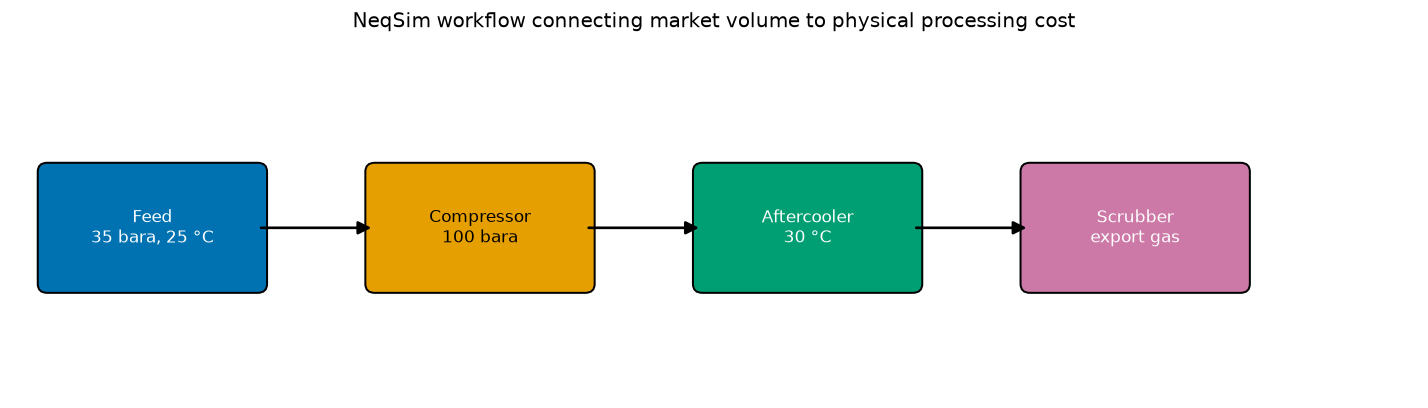

In [14]:
figure, axis = plt.subplots(figsize=(12, 3.5))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 3.2)
axis.axis("off")

units = [
    (1.2, "Feed\n35 bara, 25 °C", COLORS["blue"]),
    (4.0, "Compressor\n100 bara", COLORS["orange"]),
    (6.8, "Aftercooler\n30 °C", COLORS["green"]),
    (9.6, "Scrubber\nexport gas", COLORS["purple"]),
]

for position, label, color in units:
    box = FancyBboxPatch(
        (position - 0.9, 1.0),
        1.8,
        1.0,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        linewidth=1.2,
    )
    axis.add_patch(box)
    axis.text(
        position,
        1.5,
        label,
        ha="center",
        va="center",
        color="white" if color != COLORS["orange"] else "black",
    )

for start in [2.1, 4.9, 7.7]:
    arrow = FancyArrowPatch(
        (start, 1.5),
        (start + 1.0, 1.5),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.6,
        color="black",
    )
    axis.add_patch(arrow)

axis.set_title(
    "NeqSim workflow connecting market volume to physical processing cost"
)
figure.tight_layout()
plt.show()

The scrubber predicts essentially no liquid for this dry gas at the stated
conditions. That is a useful limiting case, not a guarantee for a rich or wet
field gas. The mass balance closes independently across the two product streams.

## 5. Translate process physics into a gas netback

The process boundary uses the inferior calorific value. With gas price
$P_g$ in USD/MMBtu, electricity price $P_e$ in USD/MWh, power $\dot{W}$ in MW,
and other variable cost $c_v$ in USD/MMBtu:

$$
N = P_g - c_v -
\frac{\dot{W}P_e}{\dot{Q}_{\mathrm{gas}}}
$$

Here, $N$ is the screening netback in USD/MMBtu and
$\dot{Q}_{\mathrm{gas}}$ is gas energy in MMBtu/h. Taxes, tariffs, capital,
fuel-gas loss, availability, nominations, exchange rates, and price-basis
differentials are intentionally excluded.

In [15]:
KJ_PER_MMBTU = 1_055_055.85262


def process_economics(
    process_case,
    gas_price_usd_mmbtu,
    electricity_price_usd_mwh,
    other_variable_cost_usd_mmbtu=0.18,
    operating_hours_year=8_000.0,
):
    standard_flow_sm3_h = (
        process_case["standard_flow_msm3_day"]
        * 1.0e6
        / 24.0
    )
    energy_flow_mmbtu_h = (
        standard_flow_sm3_h
        * lcv_kj_sm3
        / KJ_PER_MMBTU
    )
    electricity_cost_usd_h = (
        process_case["power_kw"]
        / 1000.0
        * electricity_price_usd_mwh
    )
    other_cost_usd_h = (
        other_variable_cost_usd_mmbtu
        * energy_flow_mmbtu_h
    )
    gross_revenue_usd_h = (
        gas_price_usd_mmbtu
        * energy_flow_mmbtu_h
    )
    margin_usd_h = (
        gross_revenue_usd_h
        - electricity_cost_usd_h
        - other_cost_usd_h
    )
    netback_usd_mmbtu = margin_usd_h / energy_flow_mmbtu_h

    return {
        "energy_flow_mmbtu_h": energy_flow_mmbtu_h,
        "gross_revenue_usd_h": gross_revenue_usd_h,
        "electricity_cost_usd_h": electricity_cost_usd_h,
        "other_cost_usd_h": other_cost_usd_h,
        "margin_usd_h": margin_usd_h,
        "netback_usd_mmbtu": netback_usd_mmbtu,
        "annual_margin_musd": (
            margin_usd_h * operating_hours_year / 1.0e6
        ),
    }

In [16]:
gas_price_scenarios = price_history[
    "Henry Hub [USD/MMBtu]"
].quantile([0.10, 0.50, 0.90])

scenario_rows = []
for percentile, gas_price in gas_price_scenarios.items():
    scenario = process_economics(
        process_case=base_process,
        gas_price_usd_mmbtu=gas_price,
        electricity_price_usd_mwh=80.0,
    )
    scenario_rows.append(
        {
            "Historical scenario": f"P{int(percentile * 100)}",
            "Gas price [USD/MMBtu]": gas_price,
            "Netback [USD/MMBtu]": scenario[
                "netback_usd_mmbtu"
            ],
            "Gross revenue [USD/h]": scenario[
                "gross_revenue_usd_h"
            ],
            "Electricity cost [USD/h]": scenario[
                "electricity_cost_usd_h"
            ],
            "Annual margin [million USD/year]": scenario[
                "annual_margin_musd"
            ],
        }
    )

economics_table = pd.DataFrame(scenario_rows)
display(economics_table.round(3))

,Historical scenario,Gas price [USD/MMBtu],Netback [USD/MMBtu],Gross revenue [USD/h],Electricity cost [USD/h],Annual margin [million USD/year]
0,P10,1.874,1.594,6523.115,348.178,44.387
1,P50,2.955,2.675,10285.915,348.178,74.489
2,P90,5.569,5.289,19384.861,348.178,147.281


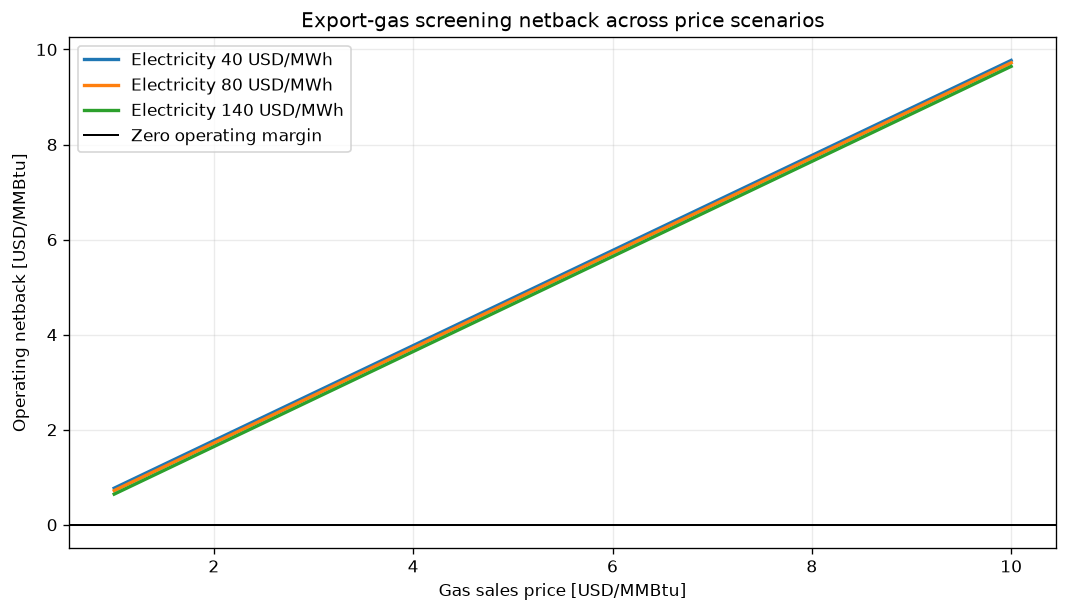

In [17]:
gas_price_grid = np.linspace(1.0, 10.0, 80)
electricity_price_cases = [40.0, 80.0, 140.0]

figure, axis = plt.subplots(figsize=(9, 5.2))
for electricity_price in electricity_price_cases:
    netbacks = [
        process_economics(
            process_case=base_process,
            gas_price_usd_mmbtu=gas_price,
            electricity_price_usd_mwh=electricity_price,
        )["netback_usd_mmbtu"]
        for gas_price in gas_price_grid
    ]
    axis.plot(
        gas_price_grid,
        netbacks,
        linewidth=2.0,
        label=f"Electricity {electricity_price:.0f} USD/MWh",
    )

axis.axhline(
    0.0,
    color="black",
    linewidth=1.2,
    label="Zero operating margin",
)
axis.set_title("Export-gas screening netback across price scenarios")
axis.set_xlabel("Gas sales price [USD/MMBtu]")
axis.set_ylabel("Operating netback [USD/MMBtu]")
axis.legend()

figure.tight_layout()
plt.show()

At fixed process conditions the netback is linear in sales price. Higher
electricity prices shift the curve downward because compression power is a
physical cost calculated by NeqSim. The chart is an operating screen, not a
discounted-cash-flow valuation.

## 6. Pressure and electricity-price sensitivity

Export pressure changes the compressor pressure ratio and therefore power.
Re-running the connected NeqSim model for each pressure is preferable to
scaling power with an unexplained exponent. The resulting power values feed a
two-dimensional netback map.

In [18]:
outlet_pressures_bara = np.array([70.0, 85.0, 100.0, 115.0, 130.0])
pressure_cases = []

for outlet_pressure_bara in outlet_pressures_bara:
    process_case = run_export_process(
        standard_flow_msm3_day=2.5,
        outlet_pressure_bara=outlet_pressure_bara,
    )
    pressure_cases.append(
        {
            "Outlet pressure [bara]": outlet_pressure_bara,
            "Power [MW]": process_case["power_kw"] / 1000.0,
            "Cooler duty [MW]": (
                process_case["cooler_duty_kw"] / 1000.0
            ),
            "Mass residual [-]": process_case["mass_residual"],
        }
    )

pressure_sensitivity = pd.DataFrame(pressure_cases)
display(pressure_sensitivity.round(6))

,Outlet pressure [bara],Power [MW],Cooler duty [MW],Mass residual [-]
0,70.0,2.739899,-3.306329,0.0
1,85.0,3.598444,-4.510915,0.0
2,100.0,4.352227,-5.599904,0.0
3,115.0,5.028076,-6.594810,0.0
4,130.0,5.643484,-7.508394,0.0


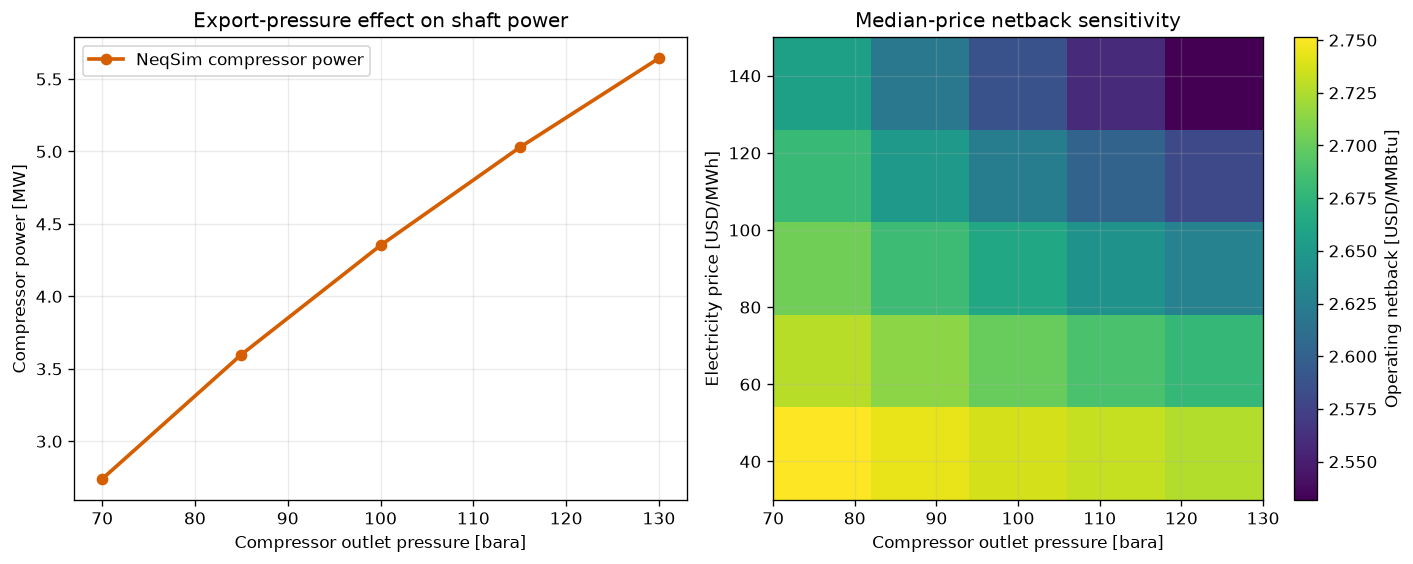

In [19]:
electricity_prices_usd_mwh = np.array(
    [30.0, 60.0, 90.0, 120.0, 150.0]
)
median_gas_price = float(gas_price_scenarios.loc[0.50])
netback_map = np.zeros(
    (
        len(electricity_prices_usd_mwh),
        len(outlet_pressures_bara),
    )
)

for row_index, electricity_price in enumerate(
    electricity_prices_usd_mwh
):
    for column_index, power_mw in enumerate(
        pressure_sensitivity["Power [MW]"]
    ):
        synthetic_case = dict(base_process)
        synthetic_case["power_kw"] = power_mw * 1000.0
        netback_map[row_index, column_index] = process_economics(
            process_case=synthetic_case,
            gas_price_usd_mmbtu=median_gas_price,
            electricity_price_usd_mwh=electricity_price,
        )["netback_usd_mmbtu"]

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(
    pressure_sensitivity["Outlet pressure [bara]"],
    pressure_sensitivity["Power [MW]"],
    color=COLORS["red"],
    marker="o",
    linewidth=2.2,
    label="NeqSim compressor power",
)
axes[0].set_title("Export-pressure effect on shaft power")
axes[0].set_xlabel("Compressor outlet pressure [bara]")
axes[0].set_ylabel("Compressor power [MW]")
axes[0].legend()

image = axes[1].imshow(
    netback_map,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    extent=[
        outlet_pressures_bara.min(),
        outlet_pressures_bara.max(),
        electricity_prices_usd_mwh.min(),
        electricity_prices_usd_mwh.max(),
    ],
)
axes[1].set_title("Median-price netback sensitivity")
axes[1].set_xlabel("Compressor outlet pressure [bara]")
axes[1].set_ylabel("Electricity price [USD/MWh]")
colorbar = figure.colorbar(image, ax=axes[1])
colorbar.set_label("Operating netback [USD/MMBtu]")

figure.tight_layout()
plt.show()

Compressor power rises monotonically with outlet pressure. At a fixed gas
price, the highest netback occurs in the low-pressure, low-electricity-cost
corner. A real design cannot select that corner unless downstream pressure and
product-delivery constraints are satisfied.

## 7. Verification checks

Assertions cover the source snapshot, thermodynamic properties, process
balances, solver trends, and economics. Broad physical bounds are intentional:
they detect unit or API errors without pretending this synthetic gas is a
certified custody-transfer composition.

In [20]:
checks = {
    "Brent snapshot has 78 monthly values": len(brent_monthly) == 78,
    "Henry Hub snapshot has 78 monthly values": (
        len(henry_hub_monthly) == 78
    ),
    "Price dates align one-to-one": len(price_history) == 78,
    "All embedded prices are positive": (
        price_history[
            ["Brent [USD/bbl]", "Henry Hub [USD/MMBtu]"]
        ].to_numpy()
        > 0.0
    ).all(),
    "Brent 2025 annual mean matches EIA rounding": np.isclose(
        brent_monthly.loc[
            brent_monthly["Date"].dt.year == 2025,
            "Brent [USD/bbl]",
        ].mean(),
        69.14,
        atol=0.05,
    ),
    "Henry Hub 2025 annual mean matches EIA rounding": np.isclose(
        henry_hub_monthly.loc[
            henry_hub_monthly["Date"].dt.year == 2025,
            "Henry Hub [USD/MMBtu]",
        ].mean(),
        3.52,
        atol=0.05,
    ),
    "Gas composition closes": np.isclose(
        sum(gas_composition.values()),
        1.0,
        atol=1.0e-12,
    ),
    "Standard density is plausible": (
        0.60 < standard_density_kg_sm3 < 0.90
    ),
    "Molar mass is plausible": 15.0 < molar_mass_g_mol < 22.0,
    "LCV is plausible": 30_000.0 < lcv_kj_sm3 < 45_000.0,
    "GCV exceeds LCV": gcv_kj_sm3 > lcv_kj_sm3,
    "Relative density is plausible": 0.50 < relative_density < 0.80,
    "Compressor consumes power": base_process["power_kw"] > 0.0,
    "Aftercooler rejects heat": base_process["cooler_duty_kw"] < 0.0,
    "Base mass balance closes": abs(
        base_process["mass_residual"]
    ) < 1.0e-10,
    "Scrubber gas is at its temperature target": np.isclose(
        base_process["gas_temperature_c"],
        30.0,
        atol=0.05,
    ),
    "Pressure cases have finite results": np.isfinite(
        pressure_sensitivity.select_dtypes(include="number")
    ).all().all(),
    "Power rises with export pressure": (
        np.diff(pressure_sensitivity["Power [MW]"]) > 0.0
    ).all(),
    "Every pressure-case balance closes": (
        pressure_sensitivity["Mass residual [-]"].abs() < 1.0e-10
    ).all(),
    "Netback rises with gas price": (
        np.diff(economics_table["Netback [USD/MMBtu]"]) > 0.0
    ).all(),
    "Netback map is finite": np.isfinite(netback_map).all(),
}

failed_checks = [
    check_name
    for check_name, passed in checks.items()
    if not passed
]
assert not failed_checks, failed_checks

print(f"All {len(checks)} engineering checks passed.")

All 21 engineering checks passed.


## 8. Assumptions and validity limits

- EIA Brent and Henry Hub are public benchmark observations, not Norwegian
  transfer prices, European hub prices, or project forecasts.
- Monthly arithmetic statistics ignore daily weighting and serial dependence.
- The gas composition is synthetic and dry; validate the EOS and composition
  against laboratory or custody-transfer data before design use.
- A single compressor stage is a screening abstraction. Mechanical limits,
  polytropic maps, anti-surge control, driver efficiency, and multi-stage
  intercooling can materially change power.
- The scrubber is an equilibrium separator, not a droplet-removal design.
- Netback excludes capital, taxes, tariffs, fuel loss, availability, financing,
  exchange rates, hedges, and price-basis differentials.
- Neither oil-energy equivalence nor historical quantiles constitute a forecast.

## Troubleshooting

- If `neqsim` is missing in Colab, rerun the setup cell once and then run all
  cells in order.
- If live Excel refresh fails, keep using the embedded snapshot; EIA workbook
  layout and network availability are outside the simulation.
- If a richer gas produces liquid, retain both separator products in the mass
  balance and evaluate hydrocarbon dew-point control.
- If compression fails at a high ratio, introduce realistic staging and
  intercooling rather than weakening assertions.
- If comparing with a European contract, replace Henry Hub with an authoritative
  contract-compatible series and document currency, location, and energy basis.

## Summary

The repaired tutorial preserves the original oil-price video, literature links,
EIA Brent analysis, EIA Henry Hub analysis, and both price figures. It replaces
brittle workbook row skipping with a dated official snapshot, then connects
price statistics to SRK thermodynamics, ISO 6976 gas quality, a real NeqSim
compression/cooling/separation workflow, mass closure, and an auditable operating
netback. Price, export pressure, and electricity cost remain explicit,
replaceable inputs.

## Further exercises

1. Replace Henry Hub with a licensed or public European hub series and quantify
   the location-basis effect.
2. Add two compressor stages with intercooling and compare total shaft power.
3. Enrich the gas with C₃–C₆ components and evaluate liquid dropout.
4. Add driver efficiency, fuel-gas use, and direct CO₂ emissions.
5. Build a discounted cash-flow model with capital, tariff, tax, and availability.
6. Compare SRK with PR and a validated model for a CO₂-rich gas.

## Authoritative references

- [EIA Europe Brent spot-price history](
  https://www.eia.gov/dnav/pet/hist/rbrtem.htm)
- [EIA Henry Hub natural-gas spot-price history](
  https://www.eia.gov/dnav/ng/hist/rngwhhdM.htm)
- [EIA Short-Term Energy Outlook](
  https://www.eia.gov/outlooks/steo/)
- [NeqSim documentation and Python integration](
  https://equinor.github.io/neqsim/)
- [NeqSim process examples](
  https://equinor.github.io/neqsim/process/)
- [NeqSim ISO 6976 calorific-value documentation](
  https://github.com/equinor/neqsim/blob/master/
  docs/standards/iso6976_calorific_values.md)
- ISO 6976:2016, *Natural gas — Calculation of calorific values, density,
  relative density and Wobbe indices from composition*.